In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import visual as vis

# Definiendo un plotter

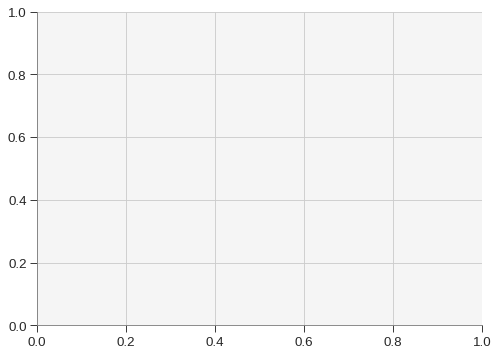

In [2]:
vis.Plotter()

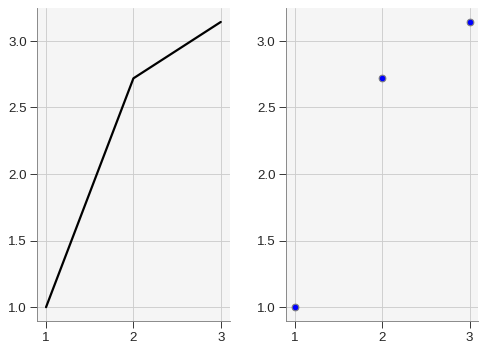

In [3]:
v = vis.Plotter(1,2)
x = np.array([1,2,3])
y = np.array([1,2.718281828459045,3.141592653589793])

# Las funciones de graficación son un subconjunto de las de matplotlib
v.plot(1, x, y)

# Se usan los mismos parámetros de las funciones de matplotlib, 
# pero deben pasarse en forma de diccionario.
v.scatter(2, x, y, dict(fc = 'blue', ec = 'gray'))

v.show()

# Parámetros de la figura y de los ejes de cada subgráfica

Los parámetros para la figura, los ejes y las funciones de graficación se deben pasar como diccionarios. Existen al menos dos opciones:

1. Definiendo un diccionario como se hace normalmente en Python:
```python
d1 = {'par1':'val1', 'par2':'val2', ...}
```

2. Usando la función `dict()` para crear un diccionario: 
```python
d1, dict(par1 = 'val1', par2 = 'val2'
```
Una dez definido el diccionario, se puede usar, por ejemplo, como sigue:

```python
v = vis.Plotter(1, 2, d1)
v.plot(x, y, d1)
```


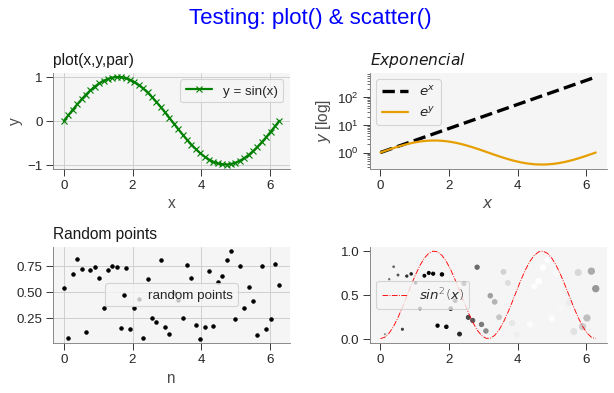

In [4]:
# Parámetros para la figura
fig_par ={'figsize':(8,5)}

# Parámetros para las subgráficas (lista de diccionarios)
axis_par = [
    # Subgráfica 1
    {'title':'plot(x,y,par)', 'xlabel':'x', 'ylabel':'y'},
    # Sibgráfica 2
    {'title':'$Exponencial$', 'yscale':'log', 'xlabel':'$x$', 'ylabel':'$y$ [log]'},
    # Subgráfica 3
    dict(title='Random points', xlabel='n')]

# Parámetros para el título
title_par = dict(color='blue', fontsize=20)

# Título de la figura
titulo = 'Testing: plot() & scatter()'

# Se define un arreglo de (2 x 2) subgráficas
v = vis.Plotter(2, 2, axis_par, fig_par, titulo, title_par)
    
x = np.linspace(0, 2 * np.pi, 50)
y = np.sin(x)
r = 0.9 * np.random.rand(len(x))

# Primera subgráfica
plot_par = {'marker':'x', 'color':'green', 'ls':'-','label':'y = sin(x)'}
v.plot(1, x, y, plot_par)

# Segunda subgráfica
v.plot(2, x, np.exp(x), dict(ls='--', lw=3.0, label='$e^x$'))
v.plot(2, x, np.exp(y), {'lw':2.0, 'label':'$e^y$'})

# Tercera subgráfica
v.scatter(3, x, r, {'marker':'.', 'label':'random points'})

# Cuarta subgráfica
v.scatter(4, x, r, {'s':x*5, 'c':y})
v.plot(4, x, y*y, {'color':'r', 'ls':'-.', 'lw':0.80, 'label':'$sin^2(x)$'})

# Acciones sobre subconjuntos de subgráficas
v.grid([2,4]) # se activa la rejilla en las subgráficas 2 y 4
v.legend(par = dict(frameon=True)) # se activan las leyendas en todas las subgráficas
v.show() # similar a plt.show()

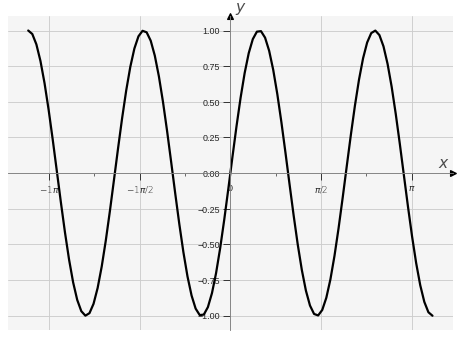

In [21]:
v = vis.Plotter(1,1)

x = np.linspace(-3.5, 3.5, 100)
v.plot(1, x, np.sin(x*np.pi))

trig = True

ejes = True

if ejes:
    v.set_coordsys(1, trig)
else:
    ax = v.axes(1)
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    v.set_ticks(ax, xticks, yticks, trig)
        
v.show()

# Elementos útiles para Modelación Computacional

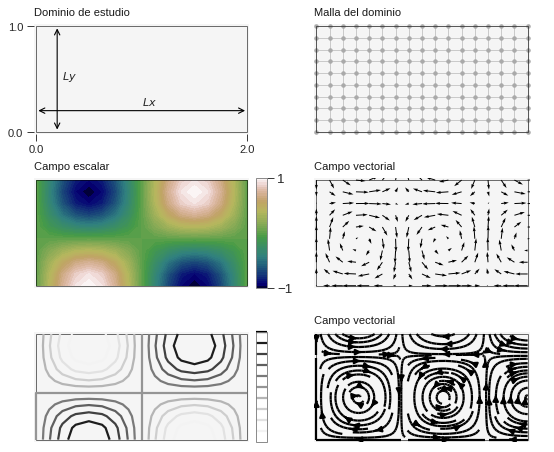

In [22]:
# Tamaño del dominio
Lx = 2.0
Ly = 1.0

# Número de nodos en cada eje
Nx = 15
Ny = 8

# Tamaño de la malla en cada dirección
hx = Lx / (Nx+1)
hy = Ly / (Ny+1)

#print('hx = {}, hy = {}'.format(hx, hy))

# Número total de nodos incluyendo las fronteras
NxT = Nx + 2
NyT = Ny + 2

# Coordenadas de la malla
xn = np.linspace(0,Lx,NxT)
yn = np.linspace(0,Ly,NyT)
xg, yg = np.meshgrid(xn, yn, indexing='ij')

# Definición de un campo escalar en cada punto de la malla
T = np.zeros((NxT, NyT))

# Asignamos un valor a cada entrada del arreglo
for i in range(NxT):
    for j in range(NyT):
        T[i,j] = np.sin(np.pi*i/8) * np.cos(np.pi*j/8)

A = 1.0
alpha = 1.25
U = -A * np.cos(np.pi * alpha * yg) * np.sin(np.pi * alpha * xg)
V =  A * np.sin(np.pi * alpha * yg) * np.cos(np.pi * alpha * xg)

a_p = dict(aspect = 'equal')
axis_par = [a_p for i in range(0,6)]
#axis_par.append(dict(projection='3d', aspect='equal'))

v = vis.Plotter(3,2, axis_par, dict(figsize=(8,6)))

v.set_canvas(1, Lx, Ly)
v.draw_domain(1, xg, yg)
v.axes(1).set_title('Dominio de estudio', fontsize=10)

v.set_canvas(2, Lx, Ly)
v.plot_mesh2D(2, xg, yg, nodeson = True)
v.plot_frame(2, xg, yg, ticks=False)
v.axes(2).set_title('Malla del dominio', fontsize=10)

cax = v.set_canvas(3, Lx, Ly)
c = v.contourf(3, xg, yg, T, {'levels':50, 'cmap':'gist_earth'})
v.fig.colorbar(c, cax=cax, ticks = [T.min(), T.max()], shrink=0.5, orientation='vertical')
v.plot_frame(3, xg, yg, ticks=False)
v.axes(3).set_title('Campo escalar', fontsize=10)

v.set_canvas(4, Lx, Ly)
v.quiver(4, xg, yg, U, V, dict())
v.plot_frame(4, xg, yg, ticks=False)
v.axes(4).set_title('Campo vectorial', fontsize=10)

cax = v.set_canvas(5, Lx, Ly)

v.plot_frame(5, xg, yg, ticks=False)

c = v.contour(5, xg, yg, T, {'levels':10, 'cmap':'Greys'})
v.fig.colorbar(c, cax=cax, ticks = [], shrink=0.5, orientation='vertical')
v.axes(3).set_title('Campo escalar', fontsize=10)

v.set_canvas(6, Lx, Ly)
v.streamplot(6, xg, yg, U, V)
v.plot_frame(6, xg, yg, ticks=False)
v.axes(6).set_title('Campo vectorial', fontsize=10)

v.fig.tight_layout(h_pad=0.5, w_pad=2.0)
v.show()

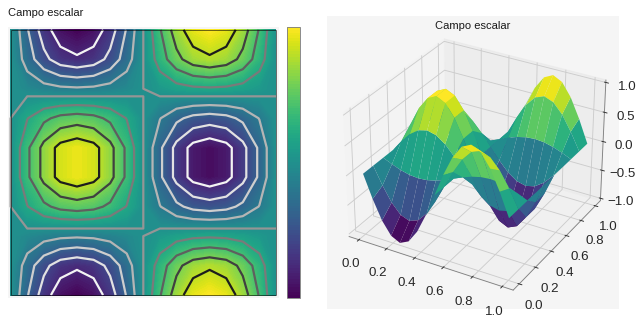

In [23]:
# Tamaño del dominio
Lx = 1.0
Ly = 1.0

# Número de nodos en cada eje
Nx = 15
Ny = 8

# Tamaño de la malla en cada dirección
hx = Lx / (Nx+1)
hy = Ly / (Ny+1)

#print('hx = {}, hy = {}'.format(hx, hy))

# Número total de nodos incluyendo las fronteras
NxT = Nx + 2
NyT = Ny + 2

# Coordenadas de la malla
xn = np.linspace(0,Lx,NxT)
yn = np.linspace(0,Ly,NyT)
xg, yg = np.meshgrid(xn, yn, indexing='ij')

# Definición de un campo escalar en cada punto de la malla
T = np.zeros((NxT, NyT))

# Asignamos un valor a cada entrada del arreglo
for i in range(NxT):
    for j in range(NyT):
        T[i,j] = np.sin(np.pi*i/8) * np.cos(np.pi*j/8)

A = 1.0
alpha = 2.0
U = -A * np.cos(np.pi * alpha * yg) * np.sin(np.pi * alpha * xg)
V =  A * np.sin(np.pi * alpha * yg) * np.cos(np.pi * alpha * xg)

axis_par = [dict(aspect = 'equal'), dict(projection='3d', aspect='auto')]
v = vis.Plotter(1,2, axis_par, dict(figsize=(8,6)))

cax = v.set_canvas(1, Lx, Ly)
c = v.contourf(1, xg, yg, U, {'levels':100, 'cmap':'viridis'})
v.contour(1, xg, yg, U, {'levels':10, 'cmap':'Greys'})
v.fig.colorbar(c, cax=cax, ticks = [], shrink=0.5, orientation='vertical')
v.plot_frame(1, xg, yg, ticks=False)
v.axes(1).set_title('Campo escalar', fontsize=10)

v.plot_surface(2, xg, yg, U, dict(cmap='viridis'))
v.axes(2).set_title('Campo escalar', fontsize=10)

v.fig.tight_layout(h_pad=0.5, w_pad=2.0)
v.show()

In [24]:
%run "./interactivo_test.ipynb"

Output()